<a href="https://colab.research.google.com/github/harshinihh8164419-netizen/AIML-Colabb/blob/main/aiml_random.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

After SMOTE: [75 75]

Random Forest
Mean Accuracy: 99.33%


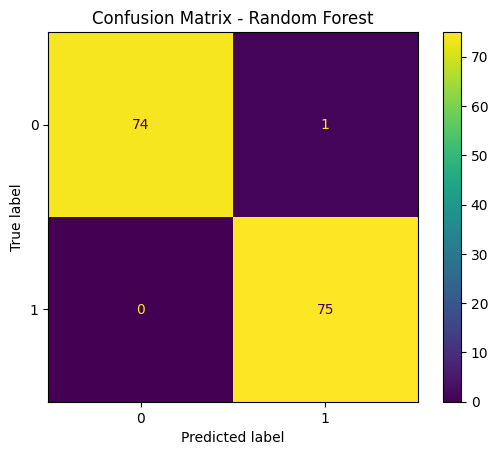

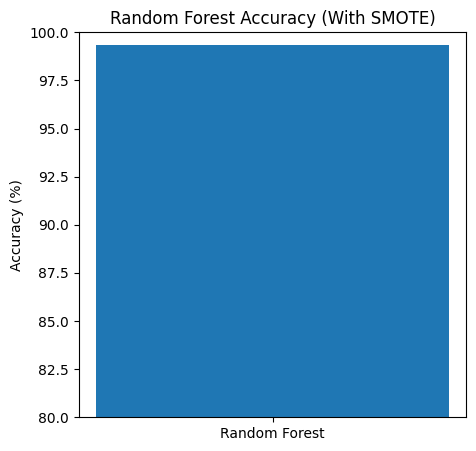

In [7]:
# An Intelligent Early Warning System for Student Risk Prediction Using Machine Learning


!pip install xgboost imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

data = pd.read_excel("augmented_student_dataset.xlsx")

data = data.drop("Student ID", axis=1)

target_column = "At Risk"

X = data.drop(target_column, axis=1)
y = data[target_column]

le = LabelEncoder()
y = le.fit_transform(y)

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = LabelEncoder().fit_transform(X[col])

X = X.fillna(X.mean())

smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

print("After SMOTE:", np.bincount(y))

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)


cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')

mean_acc = np.mean(scores)

print("\n======================")
print("Random Forest")
print("Mean Accuracy: {:.2f}%".format(mean_acc * 100))


y_pred = cross_val_predict(model, X, y, cv=cv)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

plt.figure(figsize=(5,5))

plt.bar(["Random Forest"], [mean_acc * 100])

plt.title("Random Forest Accuracy (With SMOTE)")
plt.ylabel("Accuracy (%)")

plt.ylim(80, 100)

plt.show()
